# Assignment 6

### <span style="color:chocolate"> Submission requirements </span>

Your work will not be graded if your notebook doesn't include output. In other words, <span style="color:red"> make sure to rerun your notebook before submitting to Gradescope </span> (Note: if you are using Google Colab: go to Edit > Notebook Settings  and uncheck Omit code cell output when saving this notebook, otherwise the output is not printed).

Additional points may be deducted if these requirements are not met:
    
* Comment your code;
* Each graph should have a title, labels for each axis, and (if needed) a legend. Each graph should be understandable on its own;
* Try and minimize the use of the global namespace (meaning, keep things inside functions).

``Objectives``

* This assignment connects all the pieces involved in training feed-forward fully connected neural networks (FFNN);

* You will run a full set of experiments to explore different hyperparameters and hidden layer sizes for two datasets, and then document your findings.

``Data``
* Digits MNIST
* Fashion MNIST

### Import libraries

In [3]:
%pip install numpy
%pip install keras-tuner
%pip install matplotlib
%pip install seaborn
#%pip install scikit-learn
%pip install tensorflow

import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns  # for nicer plots
sns.set(style="darkgrid")  # default style

from keras.datasets import fashion_mnist
from keras.datasets import mnist

import tensorflow as tf
from tensorflow import keras
from keras import metrics
tf.get_logger().setLevel('INFO')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 10.3 MB/s eta 0:00:00


---
### Step 1: Data ingestion

In [4]:
# Load the Fashion MNIST dataset.
(X_train_fashion, Y_train_fashion), (X_test_fashion, Y_test_fashion) = fashion_mnist.load_data()

# Load the Digits MNIST dataset.
(X_train_digits, Y_train_digits), (X_test_digits, Y_test_digits) = mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


---
### Step 2: Data preprocessing

``Fashion MNIST``

In [5]:
# Normalize
X_train_fashion = X_train_fashion / 255.
X_test_fashion = X_test_fashion / 255.

# Flatten Y_train and Y_test, so they become vectors of label values.
Y_train_fashion = Y_train_fashion.flatten()
Y_test_fashion = Y_test_fashion.flatten()

label_names = ['t-shirt', 'trouser', 'pullover', 'dress', 'coat',
               'sandal', 'shirt', 'sneaker', 'bag', 'ankle boot']

# Apply random shufflying to training examples.
np.random.seed(0)
indices = np.arange(X_train_fashion.shape[0])
shuffled_indices = np.random.permutation(indices)
X_train_fashion = X_train_fashion[shuffled_indices]
Y_train_fashion = Y_train_fashion[shuffled_indices]

``Digits MNIST``

In [6]:
# Normalize
X_train_digits = X_train_digits / 255.
X_test_digits = X_test_digits / 255.

# Flatten Y_train and Y_test, so they become vectors of label values.
Y_train_digits = Y_train_digits.flatten()
Y_test_digits = Y_test_digits.flatten()

# Apply random shufflying to training examples.
np.random.seed(0)
indices = np.arange(X_train_digits.shape[0])
shuffled_indices = np.random.permutation(indices)
X_train_digits = X_train_digits[shuffled_indices]
Y_train_digits = Y_train_digits[shuffled_indices]

---
### Step 3: Exploratory data analysis (EDA)

### <span style="color:chocolate">Exercise 1:</span> Getting to know your data (5 points)

Complete the following task:

1. Show the first training example in X_train_fashion;
2. Show the first training example in X_train_digits;
3. Display the first 5 images in X_train_digits for each class in Y_train_digits, arranged in a 10x5 grid.

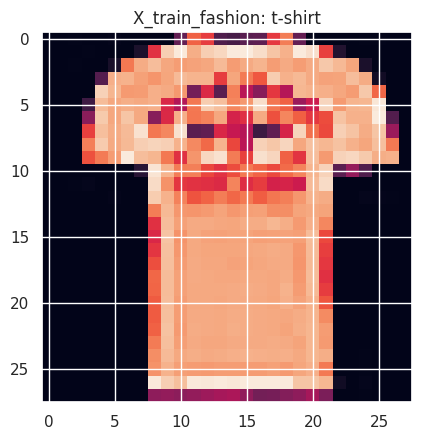

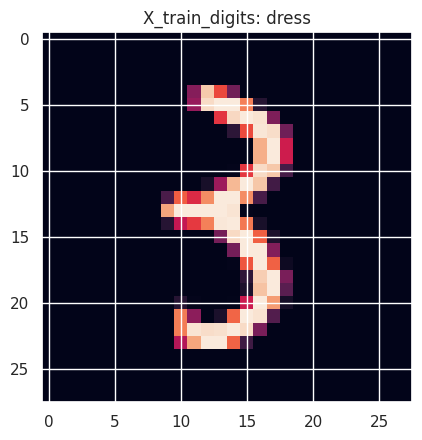

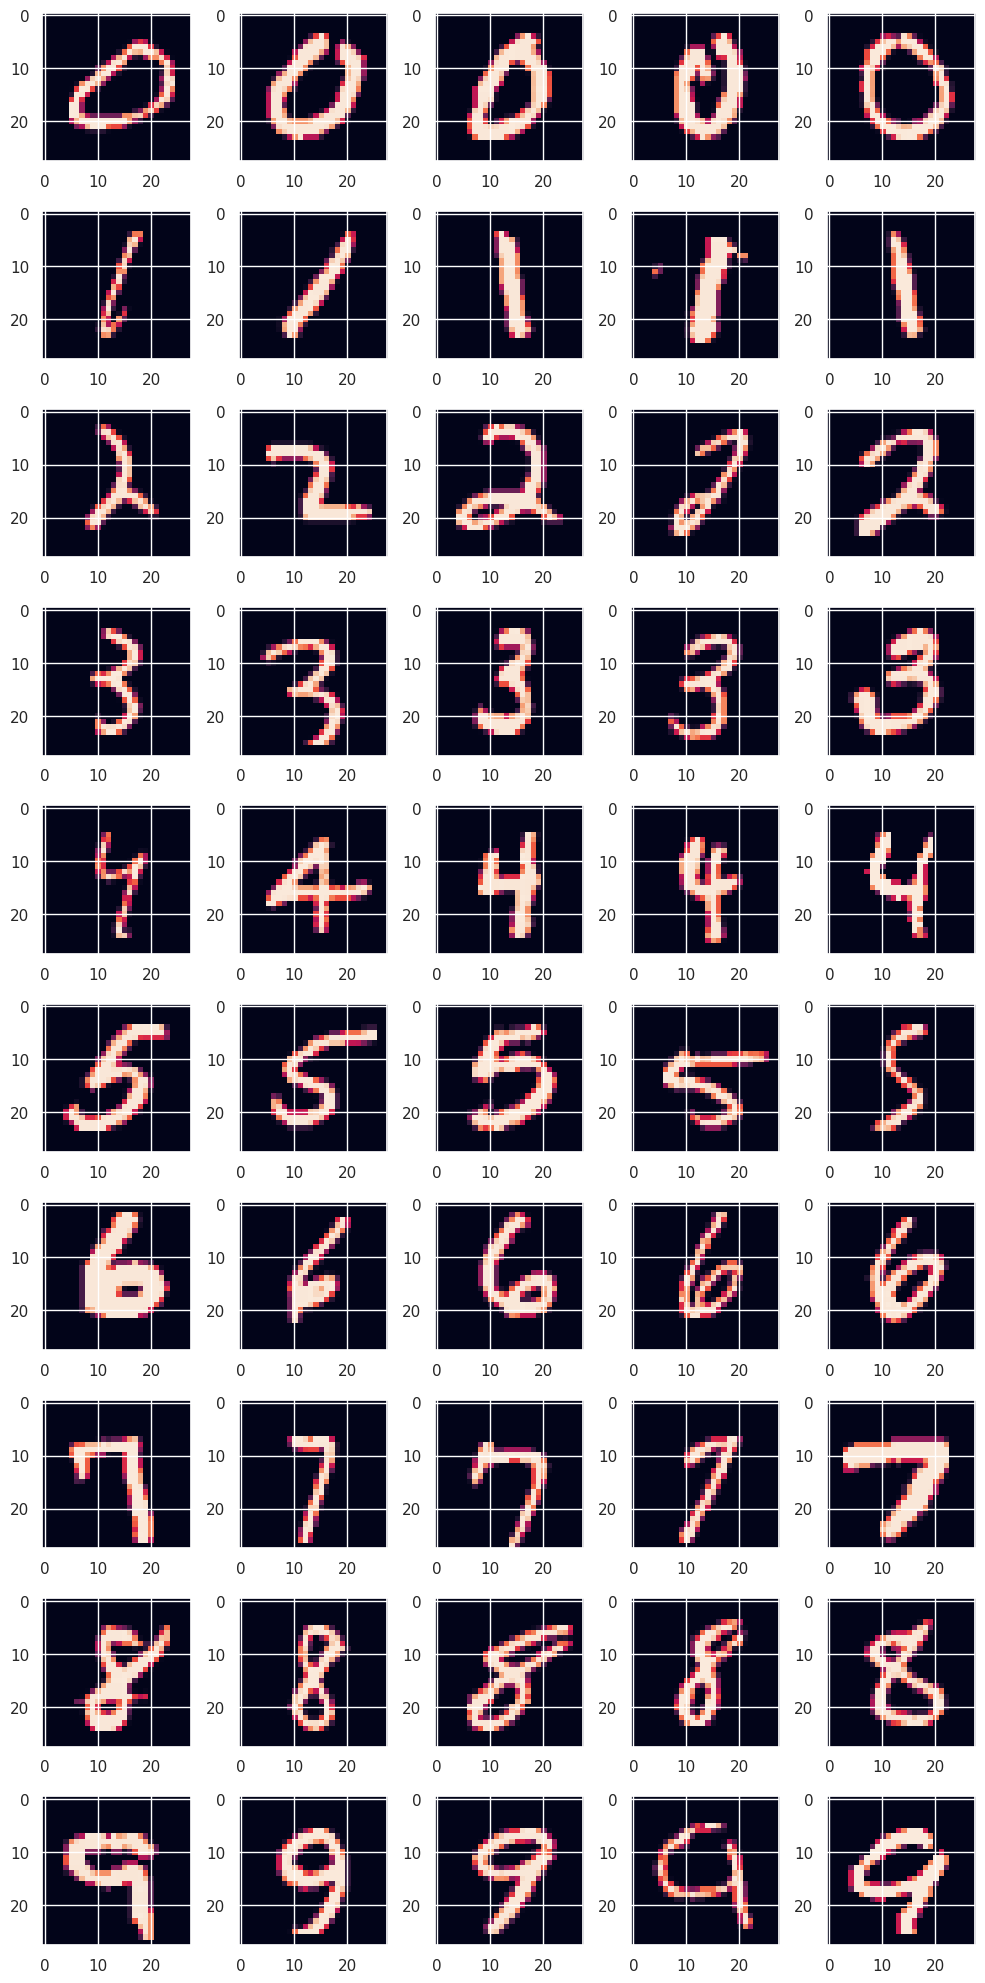

In [7]:
plt.figure()
plt.imshow(X_train_fashion[0])
plt.title(f"X_train_fashion: {label_names[Y_train_fashion[0]]}")
plt.show()


plt.figure()
plt.imshow(X_train_digits[0])
plt.title(f"X_train_digits: {label_names[Y_train_digits[0]]}")
plt.show()


fig, axes = plt.subplots(10, 5, figsize=(10, 20))

for digit_class in range(10):
    class_indices = np.where(Y_train_digits == digit_class)[0][:5]
    for col_idx, img_idx in enumerate(class_indices):
        ax = axes[digit_class, col_idx]
        ax.imshow(X_train_digits[img_idx])
plt.tight_layout()
plt.show()


### Step 4: Modeling

### <span style="color:chocolate">Exercise 2:</span> Define model (20 points)

1. Fill in the <span style="color:chocolate">build_model()</span> function below, including all the arguments listed in the function definition. Note: the activation function parameter is only for the the hidden layers; use the appropriate final classification function for the final layer.

In [8]:
def build_model(n_classes,
                hidden_layer_sizes=[],
                activation='relu',
                optimizer='SGD',
                learning_rate=0.01,
                metric='metric'):
    """Build a multi-class logistic regression model using Keras.

    Args:
    n_classes: Number of output classes in the dataset.
    hidden_layer_sizes: A list with the number of units in each hidden layer.
    activation: The activation function to use for the hidden layers.
    optimizer: The optimizer to use (SGD, Adam).
    learning_rate: The desired learning rate for the optimizer.
    metric: The desired metric.

    Returns:
    model: A tf.keras model (graph).
    """
    tf.keras.backend.clear_session()
    np.random.seed(0)
    tf.random.set_seed(0)

    # YOUR CODE HERE
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Input(shape=(28, 28)))
    model.add(tf.keras.layers.Flatten())

    for units in hidden_layer_sizes:
        model.add(tf.keras.layers.Dense(units=units, activation=activation))

    model.add(tf.keras.layers.Dense(units=n_classes, activation='softmax'))

    if optimizer == 'SGD':
        opt = tf.keras.optimizers.SGD(learning_rate=learning_rate)
        print("Initializing with SGD optimizer")
    elif optimizer == 'Adam':
        opt = tf.keras.optimizers.Adam(learning_rate=learning_rate)
        print("Initializing with Adam optimizer")
    else:
        raise ValueError("Optimizer must be SGD or Adam")

    model.compile(loss='sparse_categorical_crossentropy',
                  optimizer=opt,
                  metrics=[metric])

    return model

---
### Step 5: Experiments

You can now run a suite of experiments to see how the hyperparameters and layer sizes effect model performance.

The <span style="color:chocolate">train_and_evaluate()</span> function below can be used to run experiments and retrieve results.

Initializing with Adam optimizer
Training the digits model...


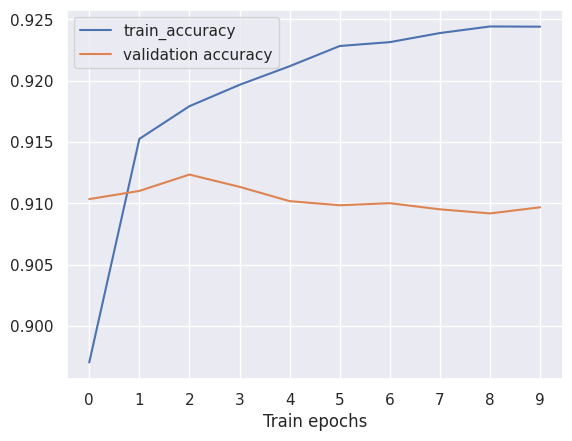

Training accuracy: 0.9244
Validation accuracy: 0.9097


In [9]:
def train_and_evaluate(data='digits',
                       hidden_layer_sizes=[],
                       activation='tanh',
                       optimizer='Adam',
                       learning_rate=0.01,
                       metric='accuracy',
                       num_epochs=10):

  # Build the model.
    model = build_model(n_classes=10,
                      hidden_layer_sizes=hidden_layer_sizes,
                      activation=activation,
                      optimizer=optimizer,
                      metric=metric,
                      learning_rate=learning_rate)

  # Select the dataset.
    if data == 'digits':
        X_train = X_train_digits
        X_test = X_test_digits
        Y_train = Y_train_digits
        Y_test = Y_test_digits

    elif data == 'fashion':
        X_train = X_train_fashion
        X_test = X_test_fashion
        Y_train = Y_train_fashion
        Y_test = Y_test_fashion
    else:
        raise 'Unsupported dataset: %s' %data

  # Train the model.
    print('Training the', data, 'model...')
    history = model.fit(
        x=X_train,
        y=Y_train,
        epochs=num_epochs,
        batch_size=64,
        validation_split=0.1,
        verbose=0)

    # Retrieve the training metrics (after each train epoch) and the final validation
    # accuracy.
    train_accuracy = history.history['accuracy']
    val_accuracy = history.history['val_accuracy']
    plt.plot(train_accuracy, label='train_accuracy')
    plt.plot(val_accuracy, label='validation accuracy')
    plt.xticks(range(num_epochs))
    plt.xlabel('Train epochs')
    plt.legend()
    plt.show()

    print('Training accuracy: %1.4f' %train_accuracy[-1])
    print('Validation accuracy: %1.4f' %val_accuracy[-1])

    return model


# run the function
model = train_and_evaluate()

### <span style="color:chocolate">Exercise 3:</span> Ablation study (50 points)

1. Conduct experiments and record the training and validation set accuracy results in the table below. You may extend the table for additional experiments as needed.
2. Report the hyperparameter values for your preferred architecture configuration.
3. Run the model once more using your preferred hyperparameter configuration.

Data | Hidden sizes | Activation| Optimizer | Learning rate | #Parameters | Training accuracy| Validation accuracy
-|-|-|-|-|-|-|-
 digits | [] | tanh | SGD |0.01| 7850 | |
 digits | [] | relu | SGD |0.01| 7850 | |
 digits | [] | relu | Adam |0.01| 7850 | |
 digits | [128] | relu | Adam |0.01| 101770 | |
 digits | [256, 128] | relu | Adam |0.01| 235146 | |
-|-|-|-|-|-|-|-
 fashion | [] | tanh | SGD |0.01| 7850 | |
 fashion | [] | relu | SGD |0.01| 7850 | |
 fashion | [] | relu | Adam |0.01| 7850 | |
 fashion | [128] | relu | Adam |0.01| 101770 | |
 fashion | [256, 128] | relu | Adam |0.01| 235146 | |

Running: 0 , digits
Initializing with SGD optimizer
Training the digits model...


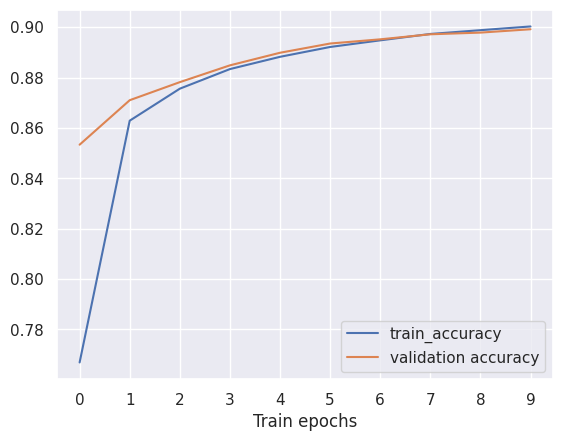

Training accuracy: 0.9003
Validation accuracy: 0.8992
Running: 1 , digits
Initializing with SGD optimizer
Training the digits model...


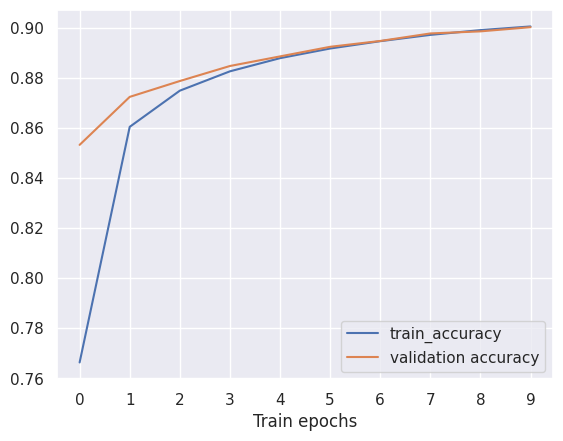

Training accuracy: 0.9005
Validation accuracy: 0.9002
Running: 2 , digits
Initializing with Adam optimizer
Training the digits model...


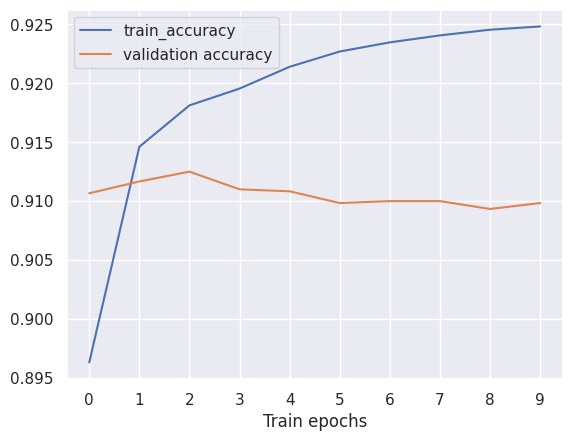

Training accuracy: 0.9248
Validation accuracy: 0.9098
Running: 3 , digits
Initializing with Adam optimizer
Training the digits model...


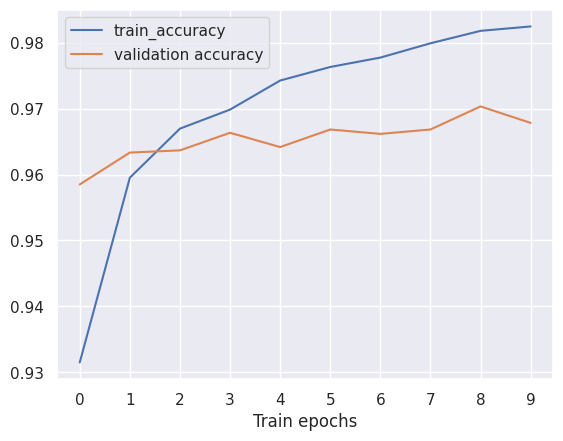

Training accuracy: 0.9825
Validation accuracy: 0.9678
Running: 4 , digits
Initializing with Adam optimizer
Training the digits model...


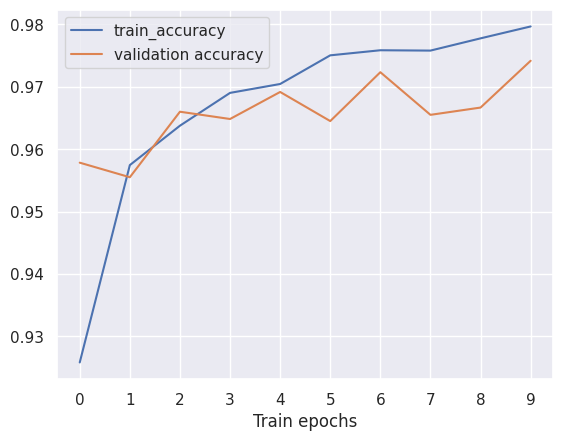

Training accuracy: 0.9797
Validation accuracy: 0.9742
Running: 5 , fashion
Initializing with SGD optimizer
Training the fashion model...


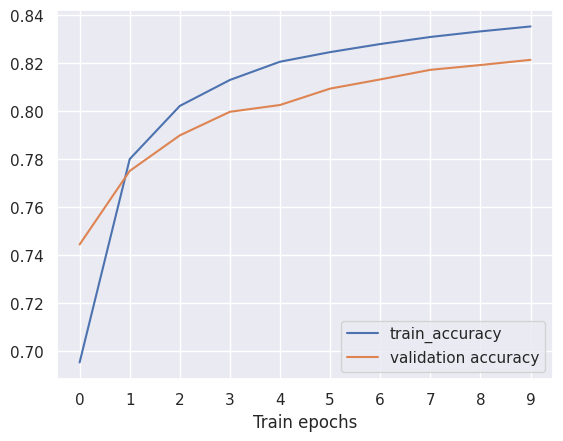

Training accuracy: 0.8354
Validation accuracy: 0.8215
Running: 6 , fashion
Initializing with SGD optimizer
Training the fashion model...


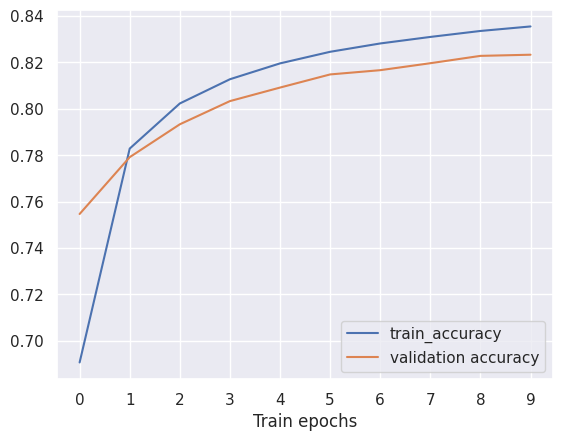

Training accuracy: 0.8355
Validation accuracy: 0.8233
Running: 7 , fashion
Initializing with Adam optimizer
Training the fashion model...


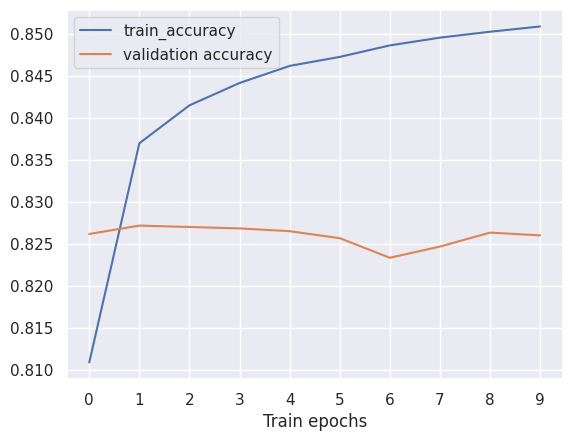

Training accuracy: 0.8509
Validation accuracy: 0.8260
Running: 8 , fashion
Initializing with Adam optimizer
Training the fashion model...


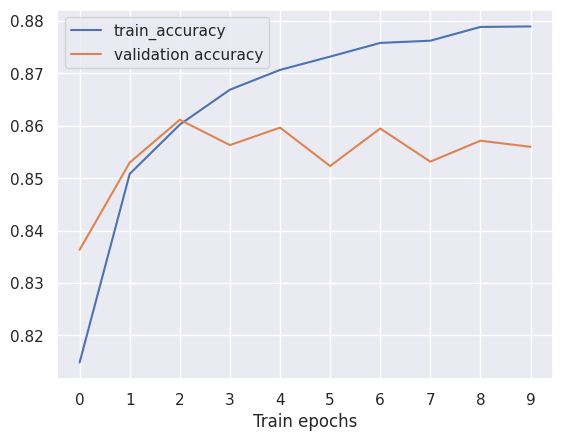

Training accuracy: 0.8790
Validation accuracy: 0.8560
Running: 9 , fashion
Initializing with Adam optimizer
Training the fashion model...


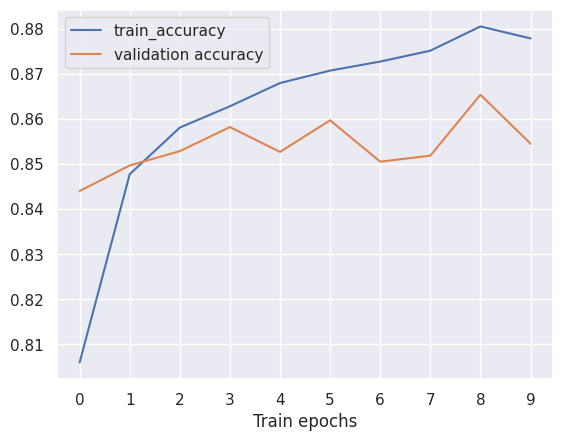

Training accuracy: 0.8778
Validation accuracy: 0.8545
      Data      Hidden  Params  Train Acc   Val Acc
0   digits          []    7850   0.900278  0.899167
1   digits          []    7850   0.900463  0.900167
2   digits          []    7850   0.924833  0.909833
3   digits       [128]  101770   0.982463  0.967833
4   digits  [256, 128]  235146   0.979667  0.974167
5  fashion          []    7850   0.835426  0.821500
6  fashion          []    7850   0.835519  0.823333
7  fashion          []    7850   0.850907  0.826000
8  fashion       [128]  101770   0.878981  0.856000
9  fashion  [256, 128]  235146   0.877815  0.854500
Running: 4-optomized , digits
Initializing with Adam optimizer
Training the digits model...


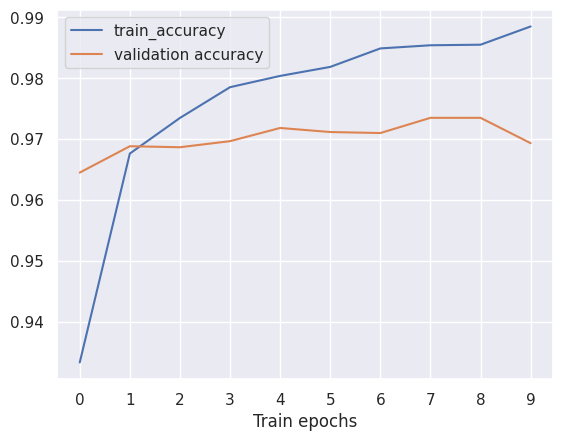

Training accuracy: 0.9885
Validation accuracy: 0.9693
Running: 9-optimized , fashion
Initializing with Adam optimizer
Training the fashion model...


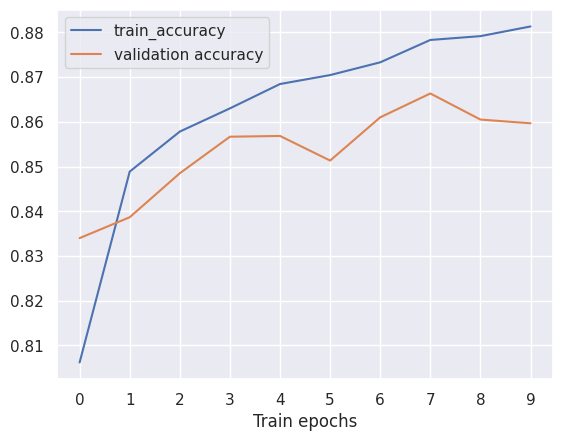

Training accuracy: 0.8813
Validation accuracy: 0.8597
      Data      Hidden  Params  Train Acc   Val Acc
0   digits  [256, 128]  235146   0.988519  0.969333
1  fashion  [256, 128]  235146   0.881315  0.859667


In [13]:
experiments = [
    {'exp_number': 0, 'data': 'digits', 'hidden': [], 'act': 'tanh', 'opt': 'SGD'},
    {'exp_number': 1, 'data': 'digits', 'hidden': [], 'act': 'relu', 'opt': 'SGD'},
    {'exp_number': 2, 'data': 'digits', 'hidden': [], 'act': 'relu', 'opt': 'Adam'},
    {'exp_number': 3, 'data': 'digits', 'hidden': [128], 'act': 'relu', 'opt': 'Adam'},
    {'exp_number': 4, 'data': 'digits', 'hidden': [256, 128], 'act': 'relu', 'opt': 'Adam'},
    {'exp_number': 5, 'data': 'fashion', 'hidden': [], 'act': 'tanh', 'opt': 'SGD'},
    {'exp_number': 6, 'data': 'fashion', 'hidden': [], 'act': 'relu', 'opt': 'SGD'},
    {'exp_number': 7, 'data': 'fashion', 'hidden': [], 'act': 'relu', 'opt': 'Adam'},
    {'exp_number': 8, 'data': 'fashion', 'hidden': [128], 'act': 'relu', 'opt': 'Adam'},
    {'exp_number': 9, 'data': 'fashion', 'hidden': [256, 128], 'act': 'relu', 'opt': 'Adam'},
]

results = []

for exp in experiments:
    print(f"Running: {exp['exp_number']} , {exp['data']}")
    model = train_and_evaluate(
        data=exp['data'],
        hidden_layer_sizes=exp['hidden'],
        activation=exp['act'],
        optimizer=exp['opt'],
        learning_rate=0.01,
        num_epochs=10
    )
    results.append({
        #'Index': exp['index'],
        'Data': exp['data'],
        'Hidden': str(exp['hidden']),
        'Params': model.count_params(),
        'Train Acc': model.history.history['accuracy'][-1],
        'Val Acc': model.history.history['val_accuracy'][-1]
    })

print(pd.DataFrame(results))

# I prefer not to overfit unless the benefit is substantial, so I've choosen the rows with indeces 4 and 9
# Row 4 a little overfitted, but the payoff is worth it to me. In the optomized run, I reduced the learning rate to try to see if I can get a better fitting and it works.
# For Row 9, I left it alone.

optimized_experiments = [
    {'exp_number': '4-optomized', 'data': 'digits', 'hidden': [256, 128], 'act': 'relu', 'opt': 'Adam', 'learning_rate': .005},
    {'exp_number': '9-optimized', 'data': 'fashion', 'hidden': [256, 128], 'act': 'relu', 'opt': 'Adam', 'learning_rate': .01},
]

results_optimized = []

for exp in optimized_experiments:
    print(f"Running: {exp['exp_number']} , {exp['data']}")
    model = train_and_evaluate(
        data=exp['data'],
        hidden_layer_sizes=exp['hidden'],
        activation=exp['act'],
        optimizer=exp['opt'],
        learning_rate=exp['learning_rate'],
        num_epochs=10
    )
    if (exp['exp_number'] == '4-optomized'):
        preferred_model_digits = model
    if (exp['exp_number'] == '9-optimized'):
        preferred_model_fashion = model

    results_optimized.append({
        'Data': exp['data'],
        'Hidden': str(exp['hidden']),
        'Params': model.count_params(),
        'Train Acc': model.history.history['accuracy'][-1],
        'Val Acc': model.history.history['val_accuracy'][-1]
    })

print(pd.DataFrame(results_optimized))


---
### Step 6: Evaluation and Generalization

### <span style="color:chocolate">Exercise 4:</span> Compute metrics (25 points)

Now that you've determined the optimal set of hyperparameters, it's time to evaluate your optimized model on the test data to gauge its performance in real-world scenarios, commonly known as inference.

1. Calculate accuracy on both train and test datasets. Note: you will need to convert the vector of predicted probabilities to a class label using the argmax operation. Hint: You can utilize the <span style="color:chocolate">model.predict()</span> method provided by tf.keras and the <span style="color:chocolate">np.max()</span> method available in NumPy; or you can use the <span style="color:chocolate">model.evaluare()</span> method provided by tf.keras directly.

2. Does the model demonstrate strong generalization capabilities? Provide an explanation based on your accuracy observations.

In [14]:
train_loss_digits, train_accuracy_digits = preferred_model_digits.evaluate(X_train_digits, Y_train_digits)
test_loss_digits, test_accuracy_digits = preferred_model_digits.evaluate(X_test_digits, Y_test_digits)

print(f"Preferred Model Train Accuracy (Digits): {train_accuracy_digits}")
print(f"Preferred Model Test Accuracy (Digits): {test_accuracy_digits}")

train_loss_fashion, train_accuracy_fashion = preferred_model_fashion.evaluate(X_train_fashion, Y_train_fashion)
test_loss_fashion, test_accuracy_fashion = preferred_model_fashion.evaluate(X_test_fashion, Y_test_fashion)

print(f"Preferred Model Train Accuracy (Fashion): {train_accuracy_fashion}")
print(f"Preferred Model Test Accuracy (Fashion): {test_accuracy_fashion}")

# Re: Digits model: yes, generalizable because the trianing accurracy is very smiliar to the test accuracy
# Re: Fashion model: yes, generalizable because the trianing accurracy is very smiliar to the test accuracy

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9873 - loss: 0.0444
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9668 - loss: 0.1830
Preferred Model Train Accuracy (Digits): 0.9850500226020813
Preferred Model Test Accuracy (Digits): 0.9724000096321106
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8890 - loss: 0.3040
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8625 - loss: 0.4046
Preferred Model Train Accuracy (Fashion): 0.8870000243186951
Preferred Model Test Accuracy (Fashion): 0.8610000014305115
